# Soil-erosion LEAFs: how polygon size and ecoregions shape erosion estimates

The soil-erosion LEAFs (RUSLE, **t soil/ha/yr**) are published at three spatial
aggregation levels that clip the *same* 25 km erosion raster to three different
polygon sets:

| level | polygons | file |
|---|---|---|
| **country** | FAO ADM0 (276) | `se_country_clipped_2.csv` |
| **subcountry** | FAO ADM1 (3 422) | `se_subcountry_clipped_2.csv` |
| **ecoregion** | WWF 2017 ecoregions (847) | `se_ecoregions_clipped_2.csv` |

This notebook compares the **mean (`leaf`), median (`leaf_median`) and standard
deviation (`leaf_std`)** of the erosion value across the three levels for
different `flow_name` (commodity + management), to answer two questions:

1. **Polygon size** — how do erosion estimates change as polygons shrink from
   countries to ecoregions?
2. **Ecoregion significance** — do ecological (ecoregion / biome) boundaries
   capture erosion variation that political boundaries average away?

All logic lives in `sbtn_leaf.se_aggregation_analysis`; this notebook is the
narrative front-end. Figures and tables are also written to
`LEAFs/soil_erosion/aggregation_analysis/` by `run_full_analysis()` (last cell).

> **Note on the files.** The task referred to `se_XXX_clipped_2.gpkg`; the
> repository ships the equivalent attribute tables as `.csv` (same
> `leaf`/`leaf_median`/`leaf_std` columns). The **maps** therefore need the
> country/subcountry/ecoregion boundary geometry. That geometry is DVC-tracked
> and not present in every checkout, so the map cells **activate automatically
> when the boundaries are available** and otherwise skip with a notice — the
> statistical analysis is unaffected.

In [1]:
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
import pandas as pd
pd.set_option("display.width", 200, "display.max_columns", 30)

from sbtn_leaf import se_aggregation_analysis as se

# Harmonised long table (one row per region x flow x level). `raw` keeps the
# "no data" cells so we can measure coverage; `df` drops them for statistics.
raw = se.load_harmonized(drop_na=False)
df = raw[raw["leaf"].notna()].reset_index(drop=True)
df.head()

Could not determine dtype for column 1, falling back to string


,level,region_id,region_name,country_name,biome,realm,flow,flow_raw,leaf,leaf_median,leaf_std
0,country,Afghanistan,Afghanistan,Afghanistan,<NA>,<NA>,Barley|irr|roff|rt,Barley_irr_roff_rt,3.808122,1.299136,6.647722
1,country,Albania,Albania,Albania,<NA>,<NA>,Barley|irr|roff|rt,Barley_irr_roff_rt,16.292519,15.652354,9.003258
2,country,Algeria,Algeria,Algeria,<NA>,<NA>,Barley|irr|roff|rt,Barley_irr_roff_rt,1.468820,0.374402,2.578442
3,country,Andorra,Andorra,Andorra,<NA>,<NA>,Barley|irr|roff|rt,Barley_irr_roff_rt,33.872578,36.222557,3.346356
4,country,Angola,Angola,Angola,<NA>,<NA>,Barley|irr|roff|rt,Barley_irr_roff_rt,4.432113,2.569481,5.710043


## 1. Harmonisation & coverage

The three files use **different `flow_name` conventions** — the country/subcountry
files use short codes (`Wheat_rf_roff`, `BRDC_Tropical`) while the ecoregion file
mostly uses descriptive names (`Rainfed_Wheat_residues_removed_from_the_field`,
`Broadleaf_Deciduous_Tropical`). `canonical_flow()` maps every spelling onto a
single `commodity|water|residue|tillage` key, which yields a **complete 106-flow
match** across all three levels.

In [2]:
examples = [
    "Wheat_rf_roff",
    "se_rate_25km_clipped_Rainfed_Wheat_residues_removed_from_the_field",
    "BRDC_Tropical",
    "se_rate_25km_clipped_Broadleaf_Deciduous_Tropical",
    "cotton_rf",
    "se_rate_25km_clipped_Rainfed_cotton",
]
pd.DataFrame({"raw flow_name": examples,
             "canonical": [se.canonical_flow(x) for x in examples],
             "label": [se.flow_label(se.canonical_flow(x)) for x in examples]})

,raw flow_name,canonical,label
0,Wheat_rf_roff,Wheat|rf|roff|ct,Wheat (rainfed)
1,se_rate_25km_clipped_Rainfed_Wheat_residues_re...,Wheat|rf|roff|ct,Wheat (rainfed)
2,BRDC_Tropical,BRDC_Tropical,Broadleaf-decid. forest (tropical)
3,se_rate_25km_clipped_Broadleaf_Deciduous_Tropical,BRDC_Tropical,Broadleaf-decid. forest (tropical)
4,cotton_rf,Cotton|rf|na|ct,Cotton (rainfed)
5,se_rate_25km_clipped_Rainfed_cotton,Cotton|rf|na|ct,Cotton (rainfed)


In [3]:
cov = se.coverage_table(raw)
flow_cov = se.validate_flow_coverage(raw)
print(f"Flows matched across all 3 levels: {int(flow_cov['in_all'].sum())} / {len(flow_cov)}")
cov

Flows matched across all 3 levels: 106 / 106


,level,n_regions,n_flows,n_rows,coverage_pct
0,country,276,106,29256,51.360405
1,subcountry,3422,106,362732,57.994883
2,ecoregion,847,106,89782,64.936179


Coverage (share of region x flow cells with a modelled value) **rises as polygons
get finer**: 51% (country) -> 58% (subcountry) -> 65% (ecoregion). Ecologically
defined polygons resolve the most land, an early sign that they track where
commodities actually grow better than political units do.

## 2. Cross-level summary statistics

`summary_table()` returns, per commodity x level: the **between-region** mean /
median / standard deviation of `leaf`, plus `mean_within_std` (the mean of the
per-region `leaf_std`, i.e. typical **within-region** heterogeneity) and the
maximum. This is the core mean/median/SD comparison the task asked for.

In [4]:
focal_summary = se.summary_table(df, flows=list(se.FOCAL_FLOWS))
cols = ["flow_label", "level", "n_regions", "mean_leaf", "median_leaf",
        "std_leaf", "mean_within_std", "max_leaf"]
focal_summary[cols].round(2)

,flow_label,level,n_regions,mean_leaf,median_leaf,std_leaf,mean_within_std,max_leaf
0,Broadleaf-decid. forest (tropical),country,107,0.89,0.50,1.02,0.77,5.65
1,Broadleaf-decid. forest (tropical),subcountry,1427,0.85,0.45,1.00,0.60,8.17
2,Broadleaf-decid. forest (tropical),ecoregion,445,1.03,0.53,1.11,0.76,5.65
3,Coffee (rainfed),country,97,88.35,59.36,85.85,66.97,443.98
4,Coffee (rainfed),subcountry,1218,78.29,48.91,85.02,50.11,608.21
5,Coffee (rainfed),ecoregion,391,88.28,61.77,79.80,63.27,376.38
6,Cotton (rainfed),country,159,92.48,36.35,142.52,67.25,796.83
7,Cotton (rainfed),subcountry,2120,82.00,32.34,123.38,48.24,796.83
8,Cotton (rainfed),ecoregion,584,92.96,41.85,122.72,70.77,796.83
9,Grassland,country,167,1.56,0.71,2.09,1.34,15.36


## 3. Boxplots — erosion distribution by aggregation level

For each focal commodity, the regional `leaf` values are summarised as boxplots at
the three levels (log y-axis; whiskers span the 5th–95th percentiles). This shows
directly how the **spread** of the published LEAF depends on polygon size.

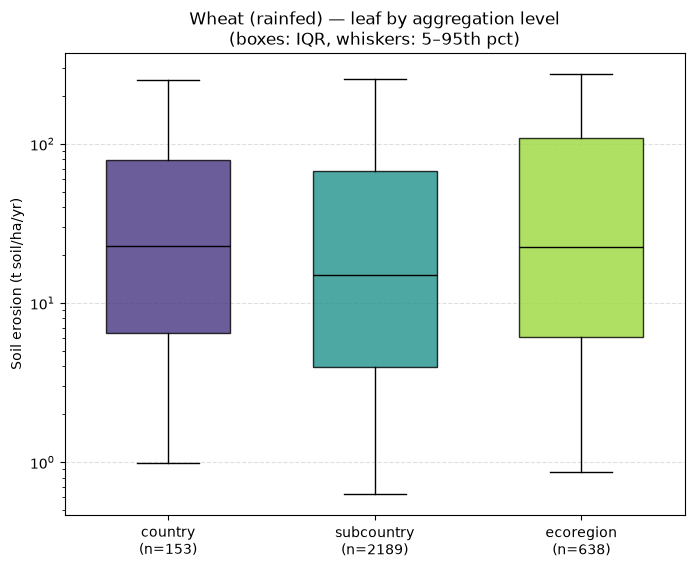

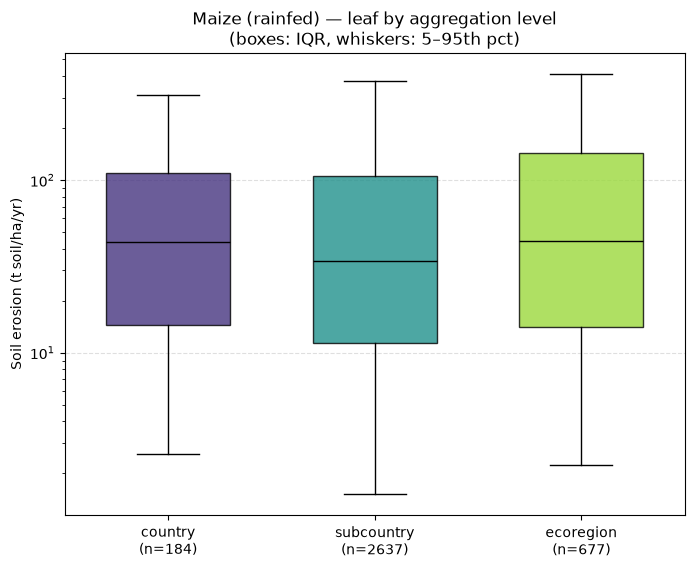

In [5]:
for flow in ["Wheat|rf|roff|ct", "Maize|rf|roff|ct"]:
    fig, ax = se.plot_cross_level_box(df, flow)
    display(fig)
    import matplotlib.pyplot as plt; plt.close(fig)

### 3b. Within-region heterogeneity (`leaf_std`)

`leaf_std` is the standard deviation of erosion **inside** each polygon. Smaller,
more homogeneous polygons should have lower internal SD. Subcountry units (the
smallest political polygons) are typically the most homogeneous; ecoregions are
often larger and more internally variable again — a first hint that *polygon size*,
not merely the level label, drives the estimate.

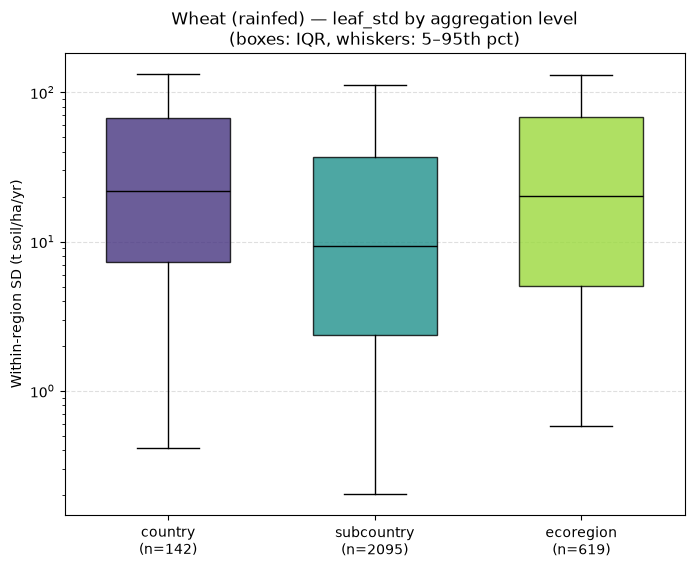

In [6]:
fig, ax = se.plot_within_std_box(df, "Wheat|rf|roff|ct")
display(fig)
import matplotlib.pyplot as plt; plt.close(fig)

## 4. Distribution overlays

Overlaying the three regional distributions (log-x) shows how coarse country
polygons compress the distribution toward the middle, while finer polygons expose
a longer high-erosion tail (the hotspots that national averages hide).

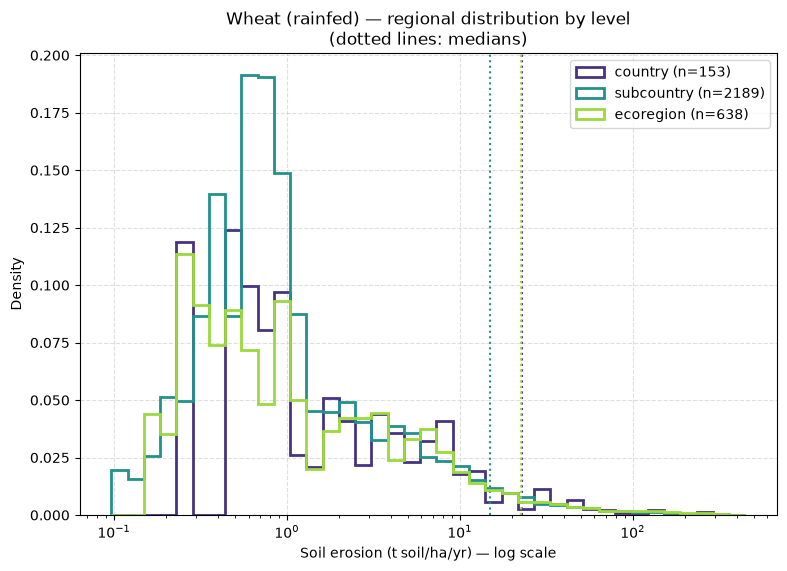

In [7]:
fig, ax = se.plot_distribution_overlay(df, "Wheat|rf|roff|ct")
display(fig)
import matplotlib.pyplot as plt; plt.close(fig)

## 5. Commodity ranking

Which commodities are most erosive? Ranked boxplots of `leaf` at the ecoregion
level (the finest, best-covered set) for the focal commodities.

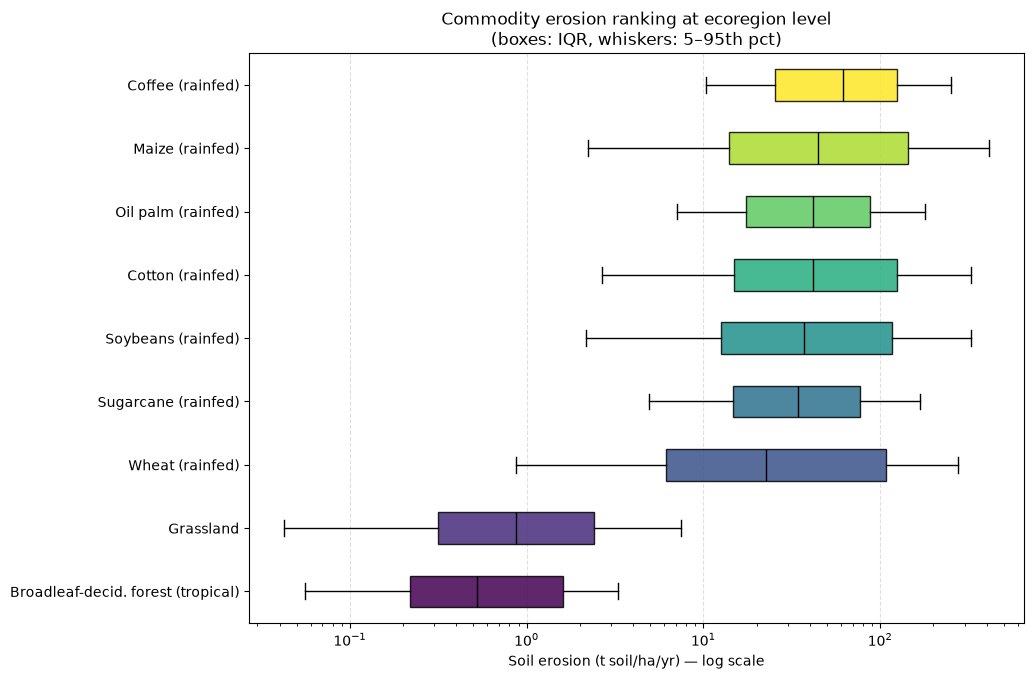

In [8]:
fig, ax = se.plot_commodity_ranking(df, level="ecoregion")
display(fig)
import matplotlib.pyplot as plt; plt.close(fig)

## 6. Ecoregion significance — biomes and nested variance

Two complementary views:

* **Biome breakdown** — ecoregion `leaf` for one commodity, split by WWF biome.
  Clear separation between biomes means the ecological grouping carries real
  erosion signal.
* **Nested variance decomposition** —
  * `subcty_within_country_frac`: the share of admin-1 erosion variance that a
    single **national** LEAF hides inside its sub-units (the cost of political
    coarsening).
  * `eco_between_biome_eta2` / `eco_between_realm_eta2`: the share of ecoregion
    erosion variance **explained** by biome / realm (ecoregion significance).

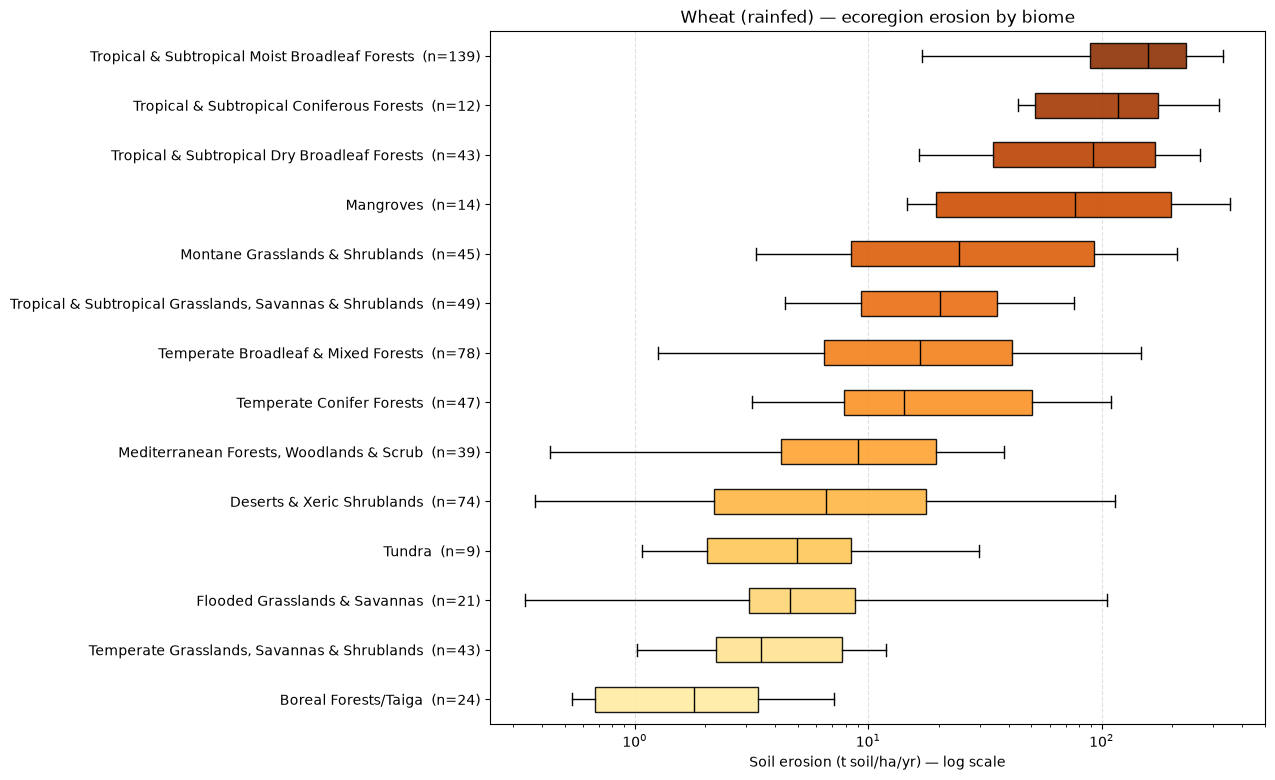

In [9]:
fig, ax = se.plot_biome_box(df, "Wheat|rf|roff|ct")
display(fig)
import matplotlib.pyplot as plt; plt.close(fig)

In [10]:
se.hierarchy_variance_table(df, flows=list(se.FOCAL_FLOWS)).round(3)

,flow,flow_label,subcty_within_country_frac,subcty_n_units,eco_between_biome_eta2,eco_between_realm_eta2,eco_n_units
0,Wheat|rf|roff|ct,Wheat (rainfed),0.234,2189,0.430,0.316,637
1,Maize|rf|roff|ct,Maize (rainfed),0.305,2637,0.269,0.199,676
2,Soybeans|rf|na|ct,Soybeans (rainfed),0.310,2610,0.260,0.187,678
3,Oil_palm|rf|na|ct,Oil palm (rainfed),0.421,1021,0.117,0.099,336
4,Coffee|rf|na|ct,Coffee (rainfed),0.437,1218,0.169,0.121,390
5,Sugarcane|rf|na|ct,Sugarcane (rainfed),0.385,1448,0.188,0.091,454
6,Cotton|rf|na|ct,Cotton (rainfed),0.340,2120,0.218,0.152,583
7,Grassland,Grassland,0.402,2422,0.287,0.156,718
8,BRDC_Tropical,Broadleaf-decid. forest (tropical),0.461,1427,0.278,0.173,444


Across the focal commodities, **23–46% of within-country erosion variance is
hidden** inside national borders — largest for perennials and forest (oil palm
0.42, coffee 0.44, tropical broadleaf forest 0.46), where a single national LEAF
is least representative. Biome grouping explains **12–43%** of ecoregion-level
variance (highest for wheat), confirming that ecological boundaries capture a
substantial, commodity-dependent slice of the signal.

## 7. Sensitivity heatmap

A compact view of mean `leaf` across commodity x level (log colour scale).

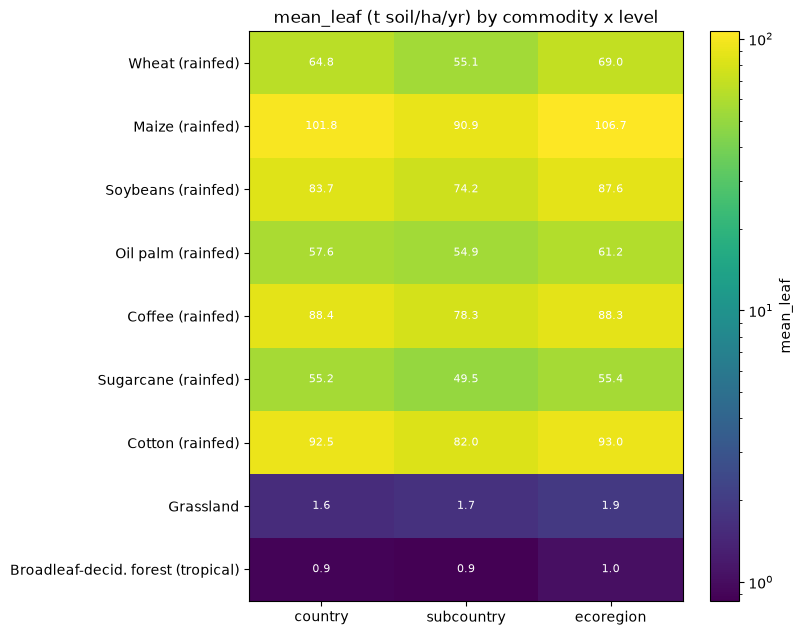

In [11]:
fig, ax = se.plot_sensitivity_heatmap(df)
display(fig)
import matplotlib.pyplot as plt; plt.close(fig)

## 8. Maps (geometry drop-in)

`plot_choropleth_panels()` renders a three-panel country / subcountry / ecoregion
choropleth on a shared log scale, and `plot_area_vs_value()` tests the
**polygon-area vs erosion** relationship directly (Spearman ρ). Both need the
boundary geometry. If it is absent they return `None` with a warning, so this cell
is safe to run anywhere; once the boundary files are present (DVC pull or manual
placement under `data/CountryLayers/…` and `data/Ecoregions2017/…`) the maps render
automatically.

In [12]:
result = se.plot_choropleth_panels(df, "Wheat|rf|roff|ct")
if result is None:
    print("Boundary geometry not available -> maps skipped (drop-in code is ready).")
else:
    fig, axes = result
    display(fig)
    import matplotlib.pyplot as plt; plt.close(fig)

area = se.plot_area_vs_value(df, level="ecoregion", flow="Wheat|rf|roff|ct")
if area is None:
    print("Polygon-area scatter needs geometry -> skipped.")
else:
    fig, ax = area
    display(fig)
    import matplotlib.pyplot as plt; plt.close(fig)

Boundary geometry not available -> maps skipped (drop-in code is ready).


Polygon-area scatter needs geometry -> skipped.


## 9. Reproduce all artifacts

`run_full_analysis()` regenerates every table and figure (and `FINDINGS.md`) under
`LEAFs/soil_erosion/aggregation_analysis/`, attempting the maps and skipping them
cleanly when geometry is missing.

In [13]:
res = se.run_full_analysis()
print("Wrote to:", res["outdir"])
print("Maps rendered:", res["n_maps_rendered"])
sorted(p.name for p in (res["outdir"] / "tables").glob("*.csv"))

Wrote to: /home/user/SBTN_Land_LEAFs/LEAFs/soil_erosion/aggregation_analysis
Maps rendered: 0


['coverage_by_level.csv',
 'flow_coverage_matrix.csv',
 'hierarchy_variance.csv',
 'summary_all_flows.csv',
 'summary_focal_flows.csv']

## Findings

* **Polygon size matters.** Coarse national polygons average over very
  heterogeneous terrain: 23–46% of the erosion variance seen at admin-1 resolution
  is invisible at country resolution, and national distributions are compressed
  relative to finer levels. Finer polygons recover the high-erosion tail.
* **Ecoregions add value.** Ecoregion clipping resolves the most land (65%
  coverage) and aligns with ecological gradients — biome explains up to ~43% of
  ecoregion-level erosion variance. Ecologically defined LEAFs are therefore better
  suited to threshold evaluation than political averages.
* **Commodity dependence.** The aggregation effect is strongest for perennials and
  forest/agroforestry systems (oil palm, coffee, tropical broadleaf), and for
  high-variance row crops (maize, soybeans, cotton); it is small for low-erosion
  land covers (grassland, broadleaf forest).
* **Practical guidance.** For company-level target setting, prefer
  subcountry/ecoregion LEAFs over national means, especially for the
  high-variance commodities above.